# MCDI501 - Estadística Computacional para la Toma de Decisiones

## Fase 1 - Exploración del conjunto de datos

### Proyecto

**Predicción del riesgo de enfermedad cardiovascular utilizando el estudio Framingham**

**Dataset:** Framingham Heart Study

**Integrantes**
- Pablo Rodríguez
- Luiskar Espinoza

**Fecha:** (completar)

---

## Objetivo

Realizar una exploración inicial del conjunto de datos Framingham Heart Study, identificando sus variables, tipos de datos y posibles relaciones, como base para posteriores análisis estadísticos e inferenciales.

# MCDI501 — Estadística Computacional para la Toma de Decisiones

## Evaluación Sumativa 1  
## Análisis Exploratorio e Inferencial

**Proyecto:** Análisis de factores cardiovasculares asociados al riesgo de enfermedad coronaria a 10 años en participantes del estudio Framingham.  

**Dataset:** Framingham Heart Study  
**Variable objetivo:** `TenYearCHD`  
**Equipo:** Grupo 6  
**Repositorio:** `mcdi501_grupo6`

---

## Propósito del notebook

Este notebook desarrolla el análisis exploratorio e inferencial del conjunto de datos Framingham Heart Study, con foco en la identificación de variables clínicas, demográficas y de hábitos de vida asociadas al riesgo de desarrollar enfermedad coronaria a 10 años.

El análisis se construye considerando la retroalimentación recibida en la evaluación formativa, reforzando especialmente:

- la clasificación estadística de variables;
- el análisis descriptivo según la naturaleza de cada variable;
- el tratamiento y documentación de valores faltantes;
- la revisión de distribuciones, asimetría y curtosis;
- el análisis de correlación entre variables clínicas;
- la estimación puntual e intervalos de confianza;
- la formulación coherente de pruebas de hipótesis;
- la verificación de supuestos estadísticos;
- la documentación reproducible del procedimiento.

## Trazabilidad metodológica del análisis

El flujo de trabajo del notebook se organiza para mantener coherencia entre el problema de investigación, los procedimientos estadísticos aplicados y los resultados reportados en el informe técnico.

La secuencia metodológica es la siguiente:

1. **Carga de librerías:** importación de herramientas científicas de Python.
2. **Carga del dataset:** lectura del archivo `framingham.csv`.
3. **Exploración inicial:** revisión de dimensiones, tipos de datos y estructura general.
4. **Calidad de datos:** identificación de valores faltantes, duplicados y posibles inconsistencias.
5. **Clasificación estadística de variables:** distinción entre variables cuantitativas, binarias nominales y ordinales.
6. **Estadística descriptiva:** cálculo de medidas de tendencia central, dispersión y forma de distribución.
7. **Visualizaciones exploratorias:** histogramas, boxplots, gráficos de barras y matriz de correlación.
8. **Estimación de parámetros:** cálculo de estimaciones puntuales e intervalos de confianza.
9. **Verificación de supuestos:** revisión de normalidad y homogeneidad de varianzas.
10. **Pruebas de hipótesis:** aplicación de pruebas t de Welch para grupos independientes.
11. **Interpretación:** análisis de resultados, limitaciones y alcance inferencial.
12. **Exportación de evidencias:** generación de tablas, gráficos y archivos de salida reproducibles.

Esta organización permite que el notebook pueda ser ejecutado de principio a fin, manteniendo trazabilidad entre código, resultados, informe técnico y repositorio GitHub.

## Contenido del notebook

1. Presentación del problema y propósito del análisis.
2. Trazabilidad metodológica del flujo de trabajo.
3. Carga de librerías.
4. Configuración de rutas del proyecto.
5. Carga del conjunto de datos.
6. Exploración inicial del dataset.
7. Revisión de calidad de datos.
8. Clasificación estadística de variables.
9. Análisis descriptivo de variables cuantitativas.
10. Análisis descriptivo de variables categóricas.
11. Análisis de valores faltantes.
12. Visualizaciones exploratorias.
13. Matriz de correlación.
14. Estimación puntual e intervalos de confianza.
15. Verificación de supuestos estadísticos.
16. Pruebas de hipótesis.
17. Tamaño del efecto.
18. Resumen de resultados.
19. Limitaciones del análisis.
20. Exportación de evidencias.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración visual
sns.set_theme(style="whitegrid")
sns.set_palette("colorblind")

# Semilla para asegurar reproducibilidad
np.random.seed(42)

## Descripción del conjunto de datos

Se utilizará el conjunto de datos **Framingham Heart Study**, proveniente de un estudio epidemiológico orientado a identificar factores de riesgo asociados al desarrollo de enfermedad coronaria.

El dataset contiene información demográfica, clínica y de hábitos de vida de 4.238 pacientes, incluyendo variables relacionadas con presión arterial, colesterol, índice de masa corporal, diabetes, tabaquismo y antecedentes médicos.

La variable objetivo corresponde a **TenYearCHD**, que indica si un paciente desarrolló enfermedad coronaria durante un período de diez años.

In [2]:
# Configuración de rutas del proyecto

from pathlib import Path

# Ruta actual desde donde se ejecuta el notebook
CURRENT_DIR = Path.cwd()

# Detectar automáticamente la raíz del repositorio
if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
elif CURRENT_DIR.name == "mcdi501_grupo6":
    PROJECT_ROOT = CURRENT_DIR
else:
    posibles_raices = [CURRENT_DIR] + list(CURRENT_DIR.parents)
    PROJECT_ROOT = None

    for ruta in posibles_raices:
        if (ruta / "README.md").exists() and (ruta / "notebooks").exists():
            PROJECT_ROOT = ruta
            break

    if PROJECT_ROOT is None:
        raise FileNotFoundError("No se pudo detectar la raíz del proyecto.")

# Rutas principales
DATA_DIR = PROJECT_ROOT / "datos"
DATA_ORIGINAL_DIR = DATA_DIR / "original"
RESULTS_DIR = PROJECT_ROOT / "resultados"

# Crear carpeta de resultados si no existe
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Ruta del dataset
DATASET = DATA_ORIGINAL_DIR / "framingham.csv"

print("Ruta actual:", CURRENT_DIR)
print("Raíz del proyecto:", PROJECT_ROOT)
print("Ruta de datos:", DATA_DIR)
print("Ruta de resultados:", RESULTS_DIR)
print("Dataset:", DATASET)

Ruta actual: C:\Users\LuiskarEspinoza\Documents\Proyectos\mcdi501_grupo6\notebooks
Raíz del proyecto: C:\Users\LuiskarEspinoza\Documents\Proyectos\mcdi501_grupo6
Ruta de datos: C:\Users\LuiskarEspinoza\Documents\Proyectos\mcdi501_grupo6\datos
Ruta de resultados: C:\Users\LuiskarEspinoza\Documents\Proyectos\mcdi501_grupo6\resultados
Dataset: C:\Users\LuiskarEspinoza\Documents\Proyectos\mcdi501_grupo6\datos\original\framingham.csv


In [3]:
# Carga del conjunto de datos

df = pd.read_csv(DATASET)

print("Dataset cargado correctamente.")
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

df.head()

Dataset cargado correctamente.
Filas: 4238
Columnas: 16


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [4]:
# Validación inicial del dataset

assert df.shape[0] > 0, "El dataset no contiene registros."
assert df.shape[1] > 0, "El dataset no contiene columnas."
assert "TenYearCHD" in df.columns, "No se encontró la variable objetivo TenYearCHD."
assert "sysBP" in df.columns, "No se encontró la variable sysBP."
assert "glucose" in df.columns, "No se encontró la variable glucose."

print("Validación inicial ejecutada correctamente.")

Validación inicial ejecutada correctamente.


### Trazabilidad de la carga y validación inicial

La carga del dataset se realiza desde la estructura del repositorio, utilizando rutas reproducibles mediante `pathlib`. Esta decisión evita depender de rutas absolutas específicas de un computador y facilita la ejecución del notebook en otros entornos.

Además, se incorporan validaciones con `assert` para comprobar que el dataset contiene registros, columnas y las variables principales del análisis: `TenYearCHD`, `sysBP` y `glucose`. Estas validaciones permiten detectar errores tempranos antes de ejecutar procedimientos estadísticos posteriores.

In [5]:
print("Filas :", df.shape[0])
print("Columnas :", df.shape[1])

Filas : 4238
Columnas : 16


In [6]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [7]:
list(df.columns)

['male',
 'age',
 'education',
 'currentSmoker',
 'cigsPerDay',
 'BPMeds',
 'prevalentStroke',
 'prevalentHyp',
 'diabetes',
 'totChol',
 'sysBP',
 'diaBP',
 'BMI',
 'heartRate',
 'glucose',
 'TenYearCHD']

In [8]:
# Información general del dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


### Interpretación

El conjunto de datos presenta 4.238 registros y 16 variables. La mayoría de las variables son numéricas, aunque varias representan variables categóricas codificadas como valores binarios (0 y 1). Además, se observa la existencia de valores faltantes en algunas variables, aspecto que deberá abordarse en etapas posteriores del proyecto.

In [9]:
# Estadísticas descriptivas

df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
male,4238.0,0.43,0.50,0.00,0.00,0.0,1.00,1.0
age,4238.0,49.58,8.57,32.00,42.00,49.0,56.00,70.0
education,4133.0,1.98,1.02,1.00,1.00,2.0,3.00,4.0
currentSmoker,4238.0,0.49,0.50,0.00,0.00,0.0,1.00,1.0
cigsPerDay,4209.0,9.00,11.92,0.00,0.00,0.0,20.00,70.0
BPMeds,4185.0,0.03,0.17,0.00,0.00,0.0,0.00,1.0
prevalentStroke,4238.0,0.01,0.08,0.00,0.00,0.0,0.00,1.0
prevalentHyp,4238.0,0.31,0.46,0.00,0.00,0.0,1.00,1.0
diabetes,4238.0,0.03,0.16,0.00,0.00,0.0,0.00,1.0
totChol,4188.0,236.72,44.59,107.00,206.00,234.0,263.00,696.0


## Asimetría y curtosis

Además de las medidas de tendencia central y dispersión, se calcularán la asimetría (skewness) y la curtosis para caracterizar la forma de la distribución de las principales variables numéricas del conjunto de datos.

In [10]:
# Variables numéricas seleccionadas
variables = ["age", "sysBP", "BMI", "glucose"]

asimetria_curtosis = pd.DataFrame({
    "Asimetría": df[variables].skew(),
    "Curtosis": df[variables].kurt()
})

asimetria_curtosis.round(3)

,Asimetría,Curtosis
age,0.228,-0.990
sysBP,1.145,2.155
BMI,0.982,2.657
glucose,6.213,58.674


### Interpretación

La asimetría permite identificar si la distribución presenta una mayor concentración de datos hacia alguno de sus extremos. Valores cercanos a cero indican distribuciones aproximadamente simétricas.

La curtosis describe el grado de concentración de los datos alrededor de la media y la presencia de valores extremos. Valores positivos indican distribuciones con colas más pesadas, mientras que valores negativos representan distribuciones más planas.

Estos indicadores complementan las medidas descriptivas tradicionales y permiten comprender mejor el comportamiento de las variables analizadas.

### Interpretación de las estadísticas descriptivas

Las estadísticas descriptivas permiten observar una primera caracterización de las variables numéricas del conjunto de datos. Se aprecia la variabilidad existente en indicadores como la presión arterial sistólica, el colesterol total y la edad, los cuales podrían influir en el riesgo de desarrollar enfermedad coronaria.

In [11]:
# Valores faltantes por variable

df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

### Análisis porcentual de valores faltantes

Además de identificar la cantidad absoluta de valores faltantes por variable, se calcula el porcentaje que representan respecto del total de registros del dataset. Esta revisión permite evaluar la magnitud real de los datos ausentes y justificar la estrategia metodológica utilizada en el análisis.

In [12]:
# Análisis de valores faltantes

faltantes = df.isna().sum().to_frame("n_faltantes")
faltantes["porcentaje"] = (faltantes["n_faltantes"] / len(df) * 100).round(2)

faltantes = faltantes[faltantes["n_faltantes"] > 0].sort_values(
    "n_faltantes",
    ascending=False
)

faltantes

,n_faltantes,porcentaje
glucose,388,9.16
education,105,2.48
BPMeds,53,1.25
totChol,50,1.18
cigsPerDay,29,0.68
BMI,19,0.45
heartRate,1,0.02


### Interpretación metodológica

Los valores faltantes se concentran principalmente en variables clínicas y demográficas como `glucose`, `education`, `BPMeds`, `totChol`, `cigsPerDay`, `BMI` y `heartRate`.

En esta etapa no se aplica imputación, ya que el objetivo es realizar un análisis exploratorio e inferencial inicial preservando la estructura original de los datos. Para cada procedimiento estadístico se utilizan los registros disponibles en las variables involucradas.

Esta decisión permite evitar introducir supuestos adicionales de imputación que podrían alterar las distribuciones originales. En fases posteriores se recomienda comparar estrategias de imputación y evaluar su impacto sobre las estimaciones, intervalos de confianza y pruebas de hipótesis.

In [13]:
print(f"Número de registros : {df.shape[0]}")
print(f"Número de variables : {df.shape[1]}")

Número de registros : 4238
Número de variables : 16


In [14]:
tipos = pd.DataFrame({
    "Variable": df.columns,
    "Tipo": df.dtypes.values
})

tipos

,Variable,Tipo
0,male,int64
1,age,int64
2,education,float64
3,currentSmoker,int64
4,cigsPerDay,float64
5,BPMeds,float64
6,prevalentStroke,int64
7,prevalentHyp,int64
8,diabetes,int64
9,totChol,float64


## Clasificación estadística de variables

Aunque varias variables del dataset están codificadas numéricamente, no todas deben interpretarse como cuantitativas. Por esta razón, se distingue entre el tipo técnico del dato y su naturaleza estadística.

Esta clasificación permite seleccionar correctamente las medidas descriptivas y los gráficos apropiados para cada variable.

In [15]:
# Clasificación estadística de variables

clasificacion_estadistica = pd.DataFrame({
    "Variable": [
        "male", "age", "education", "currentSmoker", "cigsPerDay",
        "BPMeds", "prevalentStroke", "prevalentHyp", "diabetes",
        "totChol", "sysBP", "diaBP", "BMI", "heartRate",
        "glucose", "TenYearCHD"
    ],
    "Tipo técnico": [
        str(df[col].dtype) for col in [
            "male", "age", "education", "currentSmoker", "cigsPerDay",
            "BPMeds", "prevalentStroke", "prevalentHyp", "diabetes",
            "totChol", "sysBP", "diaBP", "BMI", "heartRate",
            "glucose", "TenYearCHD"
        ]
    ],
    "Naturaleza estadística": [
        "Binaria nominal",
        "Cuantitativa discreta",
        "Ordinal",
        "Binaria nominal",
        "Cuantitativa discreta",
        "Binaria nominal",
        "Binaria nominal",
        "Binaria nominal",
        "Binaria nominal",
        "Cuantitativa continua",
        "Cuantitativa continua",
        "Cuantitativa continua",
        "Cuantitativa continua",
        "Cuantitativa continua",
        "Cuantitativa continua",
        "Binaria objetivo"
    ],
    "Uso en el análisis": [
        "Caracterización demográfica",
        "Variable clínica/demográfica",
        "Nivel educativo",
        "Hábito de tabaquismo",
        "Intensidad de consumo de tabaco",
        "Tratamiento farmacológico",
        "Antecedente clínico",
        "Antecedente clínico",
        "Condición clínica",
        "Variable biomédica",
        "Variable principal de contraste",
        "Variable biomédica",
        "Variable biomédica",
        "Variable biomédica",
        "Variable principal de contraste",
        "Variable objetivo"
    ]
})

clasificacion_estadistica

,Variable,Tipo técnico,Naturaleza estadística,Uso en el análisis
0,male,int64,Binaria nominal,Caracterización demográfica
1,age,int64,Cuantitativa discreta,Variable clínica/demográfica
2,education,float64,Ordinal,Nivel educativo
3,currentSmoker,int64,Binaria nominal,Hábito de tabaquismo
4,cigsPerDay,float64,Cuantitativa discreta,Intensidad de consumo de tabaco
5,BPMeds,float64,Binaria nominal,Tratamiento farmacológico
6,prevalentStroke,int64,Binaria nominal,Antecedente clínico
7,prevalentHyp,int64,Binaria nominal,Antecedente clínico
8,diabetes,int64,Binaria nominal,Condición clínica
9,totChol,float64,Cuantitativa continua,Variable biomédica


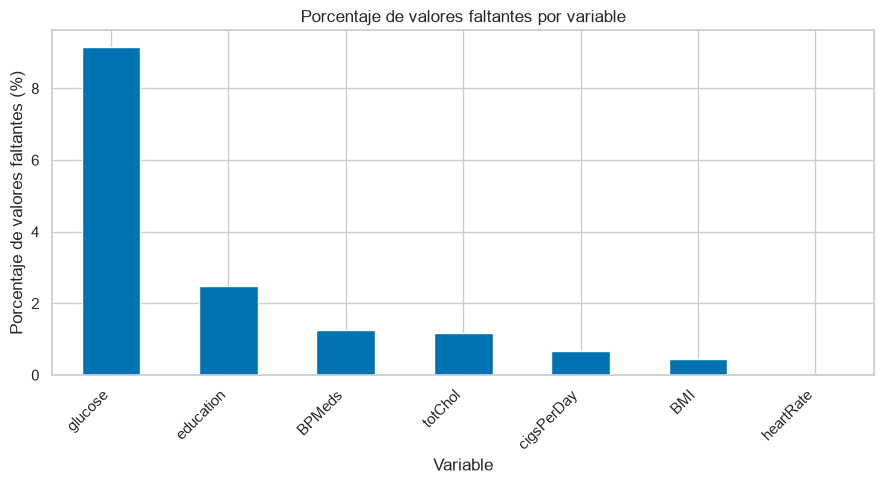

In [16]:
# Visualización de valores faltantes

plt.figure(figsize=(9, 5))
faltantes["porcentaje"].plot(kind="bar")

plt.title("Porcentaje de valores faltantes por variable")
plt.xlabel("Variable")
plt.ylabel("Porcentaje de valores faltantes (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [17]:
# Exportación de primeras evidencias descriptivas

# Variables cuantitativas usadas para la descriptiva académica
variables_cuantitativas = [
    "age",
    "cigsPerDay",
    "totChol",
    "sysBP",
    "diaBP",
    "BMI",
    "heartRate",
    "glucose"
]

# Construcción de tabla descriptiva cuantitativa
descriptiva_cuantitativa = df[variables_cuantitativas].agg([
    "count", "mean", "median", "std", "min", "max"
]).T

descriptiva_cuantitativa["asimetria"] = df[variables_cuantitativas].skew(numeric_only=True)
descriptiva_cuantitativa["curtosis"] = df[variables_cuantitativas].kurtosis(numeric_only=True)

descriptiva_cuantitativa = descriptiva_cuantitativa.round(3)

# Exportación de archivos
clasificacion_estadistica.to_csv(
    RESULTS_DIR / "clasificacion_estadistica_variables.csv",
    index=False
)

descriptiva_cuantitativa.to_csv(
    RESULTS_DIR / "descriptiva_variables_cuantitativas.csv"
)

faltantes.to_csv(
    RESULTS_DIR / "valores_faltantes.csv"
)

print("Archivos descriptivos exportados correctamente.")
print("Clasificación:", RESULTS_DIR / "clasificacion_estadistica_variables.csv")
print("Descriptiva:", RESULTS_DIR / "descriptiva_variables_cuantitativas.csv")
print("Faltantes:", RESULTS_DIR / "valores_faltantes.csv")

Archivos descriptivos exportados correctamente.
Clasificación: C:\Users\LuiskarEspinoza\Documents\Proyectos\mcdi501_grupo6\resultados\clasificacion_estadistica_variables.csv
Descriptiva: C:\Users\LuiskarEspinoza\Documents\Proyectos\mcdi501_grupo6\resultados\descriptiva_variables_cuantitativas.csv
Faltantes: C:\Users\LuiskarEspinoza\Documents\Proyectos\mcdi501_grupo6\resultados\valores_faltantes.csv


In [18]:
# Validación de evidencias exportadas

assert (RESULTS_DIR / "clasificacion_estadistica_variables.csv").exists()
assert (RESULTS_DIR / "descriptiva_variables_cuantitativas.csv").exists()
assert (RESULTS_DIR / "valores_faltantes.csv").exists()

print("Evidencias descriptivas validadas correctamente.")

Evidencias descriptivas validadas correctamente.


### Interpretación de la clasificación estadística

El análisis de calidad del conjunto de datos permite verificar que la estructura general es consistente para desarrollar el estudio estadístico. Se identificó la presencia de valores faltantes en algunas variables clínicas, mientras que no existen registros duplicados. Esta revisión entrega una base sólida para justificar las decisiones de limpieza y tratamiento de datos utilizadas posteriormente en el análisis.

# Reporte de calidad del conjunto de datos

Antes de realizar el análisis estadístico, es importante evaluar la calidad del conjunto de datos. Para ello se revisan aspectos como la cantidad de registros, tipos de variables, presencia de valores faltantes, registros duplicados y porcentaje de datos faltantes. Esta información permite determinar si es necesario realizar procesos adicionales de limpieza antes del análisis.

In [19]:
print("=" * 70)
print("REPORTE DE CALIDAD DEL DATASET")
print("=" * 70)

print(f"\nNúmero de registros : {df.shape[0]}")
print(f"Número de variables : {df.shape[1]}")

print("\nRegistros duplicados:")
print(df.duplicated().sum())

print("\nValores faltantes:")
print(df.isnull().sum())

print("\nPorcentaje de valores faltantes:")

porcentaje = (
    df.isnull().sum() /
    len(df) * 100
).round(2)

print(porcentaje)

REPORTE DE CALIDAD DEL DATASET

Número de registros : 4238
Número de variables : 16

Registros duplicados:
0

Valores faltantes:
male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

Porcentaje de valores faltantes:
male               0.00
age                0.00
education          2.48
currentSmoker      0.00
cigsPerDay         0.68
BPMeds             1.25
prevalentStroke    0.00
prevalentHyp       0.00
diabetes           0.00
totChol            1.18
sysBP              0.00
diaBP              0.00
BMI                0.45
heartRate          0.02
glucose            9.16
TenYearCHD         0.00
dtype: float64


### Interpretación

Predominan variables cuantitativas continuas relacionadas con indicadores clínicos, como presión arterial, colesterol, índice de masa corporal y glucosa. También existen variables categóricas binarias asociadas a factores de riesgo y antecedentes médicos, lo que permite aplicar distintos procedimientos estadísticos según el tipo de variable analizada.

# Análisis descriptivo de variables categóricas

Además de las variables numéricas, resulta importante analizar la distribución de las variables categóricas presentes en el conjunto de datos. Para ello se calcularán frecuencias absolutas y relativas, complementando el análisis con representaciones gráficas que permitan visualizar el comportamiento de estas variables.

In [20]:
variables_categoricas = [
    "male",
    "currentSmoker",
    "prevalentHyp",
    "diabetes",
    "TenYearCHD"
]

for variable in variables_categoricas:

    print("=" * 60)
    print(f"Variable: {variable}")
    print("=" * 60)

    frecuencias = df[variable].value_counts()

    porcentajes = (
        df[variable]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    tabla = pd.DataFrame({
        "Frecuencia": frecuencias,
        "Porcentaje (%)": porcentajes
    })

    print(tabla)
    print()

Variable: male
      Frecuencia  Porcentaje (%)
male                            
0           2419           57.08
1           1819           42.92

Variable: currentSmoker
               Frecuencia  Porcentaje (%)
currentSmoker                            
0                    2144           50.59
1                    2094           49.41

Variable: prevalentHyp
              Frecuencia  Porcentaje (%)
prevalentHyp                            
0                   2922           68.95
1                   1316           31.05

Variable: diabetes
          Frecuencia  Porcentaje (%)
diabetes                            
0               4129           97.43
1                109            2.57

Variable: TenYearCHD
            Frecuencia  Porcentaje (%)
TenYearCHD                            
0                 3594            84.8
1                  644            15.2



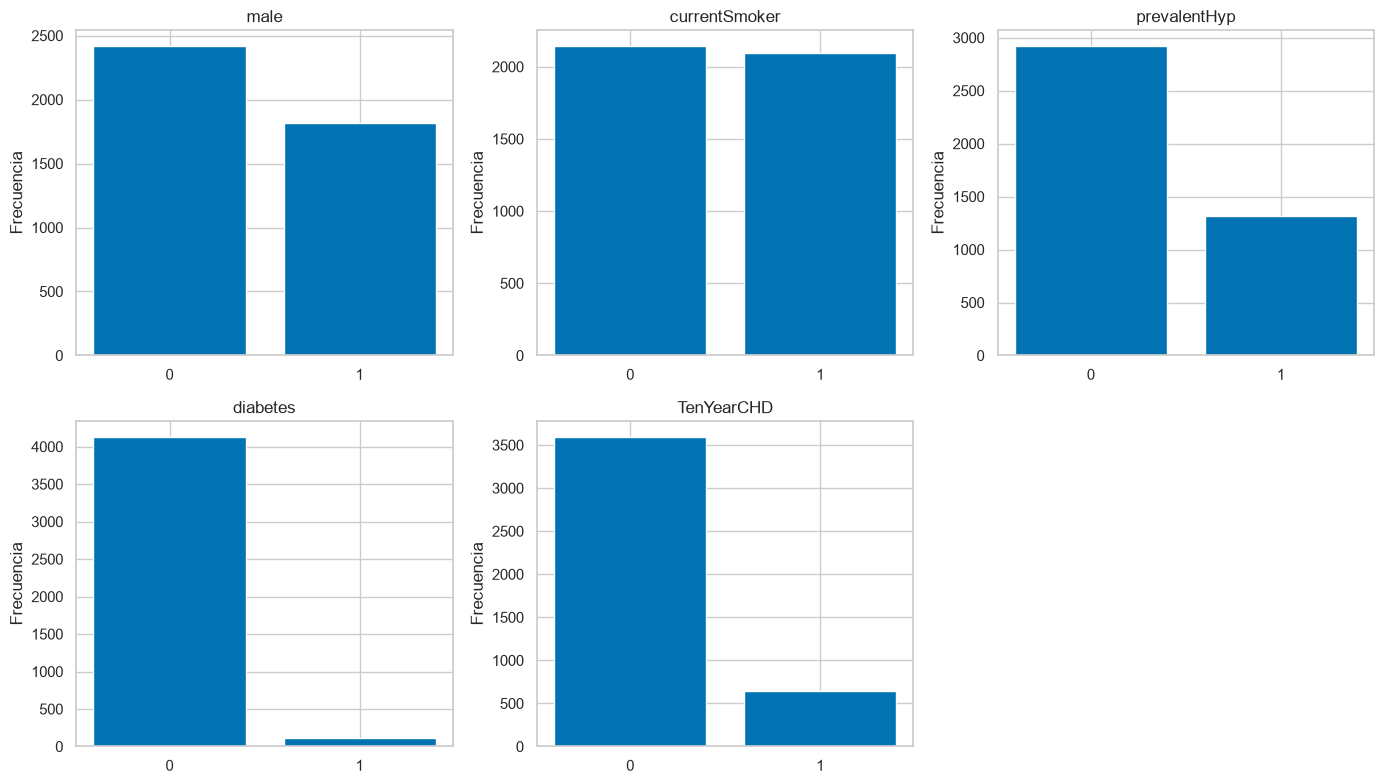

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(14,8))

axes = axes.flatten()

for i, variable in enumerate(variables_categoricas):

    conteo = df[variable].value_counts().sort_index()

    axes[i].bar(
        conteo.index.astype(str),
        conteo.values
    )

    axes[i].set_title(variable)
    axes[i].set_ylabel("Frecuencia")

# eliminar el último gráfico vacío
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

### Interpretación

El análisis de frecuencias permite observar que la mayoría de los participantes no presenta enfermedad coronaria a diez años (TenYearCHD = 0), no registra diabetes y no utiliza medicamentos para la presión arterial. Asimismo, la distribución por sexo y condición de fumador muestra una representación suficiente de ambos grupos, lo que permite realizar comparaciones estadísticas posteriores con un tamaño muestral adecuado.

# Estadística descriptiva

En esta sección se calculan medidas descriptivas para la variable **sysBP**, debido a que será la variable principal utilizada para contrastar la hipótesis del proyecto.

In [22]:
df["sysBP"].describe()

count    4238.000000
mean      132.352407
std        22.038097
min        83.500000
25%       117.000000
50%       128.000000
75%       144.000000
max       295.000000
Name: sysBP, dtype: float64

### Estadística descriptiva de variables cuantitativas

La tabla descriptiva general permite obtener una primera visión del dataset, pero mezcla variables cuantitativas con variables binarias u ordinales codificadas numéricamente. Para evitar interpretaciones incorrectas, se construye una tabla descriptiva específica solo para variables cuantitativas.

Esta separación permite reportar medidas apropiadas de tendencia central, dispersión y forma de distribución, cumpliendo con el criterio de estadística descriptiva solicitado en la evaluación.

In [23]:
# Variables cuantitativas para estadística descriptiva

variables_cuantitativas = [
    "age", "cigsPerDay", "totChol", "sysBP",
    "diaBP", "BMI", "heartRate", "glucose"
]

descriptiva_cuantitativa = df[variables_cuantitativas].agg([
    "count", "mean", "median", "std", "min", "max"
]).T

descriptiva_cuantitativa["asimetria"] = df[variables_cuantitativas].skew(numeric_only=True)
descriptiva_cuantitativa["curtosis"] = df[variables_cuantitativas].kurtosis(numeric_only=True)

descriptiva_cuantitativa = descriptiva_cuantitativa.round(3)
descriptiva_cuantitativa

,count,mean,median,std,min,max,asimetria,curtosis
age,4238.0,49.585,49.0,8.572,32.00,70.0,0.228,-0.990
cigsPerDay,4209.0,9.003,0.0,11.920,0.00,70.0,1.248,1.023
totChol,4188.0,236.722,234.0,44.590,107.00,696.0,0.871,4.132
sysBP,4238.0,132.352,128.0,22.038,83.50,295.0,1.145,2.155
diaBP,4238.0,82.893,82.0,11.911,48.00,142.5,0.714,1.277
BMI,4219.0,25.802,25.4,4.080,15.54,56.8,0.982,2.657
heartRate,4237.0,75.879,75.0,12.027,44.00,143.0,0.644,0.907
glucose,3850.0,81.967,78.0,23.960,40.00,394.0,6.213,58.674


### Interpretación

La tabla anterior resume únicamente las variables cuantitativas del conjunto de datos. Esta decisión evita interpretar como variables continuas aquellas variables que, aunque estén codificadas numéricamente, representan categorías binarias u ordinales.

La media y la mediana permiten comparar el centro de cada distribución; la desviación estándar permite evaluar la dispersión; mientras que la asimetría y la curtosis permiten describir la forma de la distribución. Estos indicadores son relevantes porque variables clínicas como `glucose`, `sysBP`, `BMI` y `totChol` pueden presentar valores extremos clínicamente plausibles.

Por esta razón, los valores extremos no se eliminan automáticamente, sino que se documentan para orientar la interpretación estadística posterior.

In [24]:
print("Media:", df["sysBP"].mean())
print("Mediana:", df["sysBP"].median())
print("Moda:", df["sysBP"].mode()[0])

Media: 132.35240679565834
Mediana: 128.0
Moda: 120.0


In [25]:
print("Desviación estándar:", df["sysBP"].std())
print("Varianza:", df["sysBP"].var())
print("Mínimo:", df["sysBP"].min())
print("Máximo:", df["sysBP"].max())
print("Rango:", df["sysBP"].max()-df["sysBP"].min())

Desviación estándar: 22.038096643544584
Varianza: 485.6777036702111
Mínimo: 83.5
Máximo: 295.0
Rango: 211.5


### Interpretación

La presión arterial sistólica presenta una amplia variabilidad entre los participantes del estudio. La comparación entre la media y la mediana permitirá evaluar preliminarmente la simetría de la distribución, mientras que la desviación estándar cuantifica la dispersión de los valores respecto del promedio.

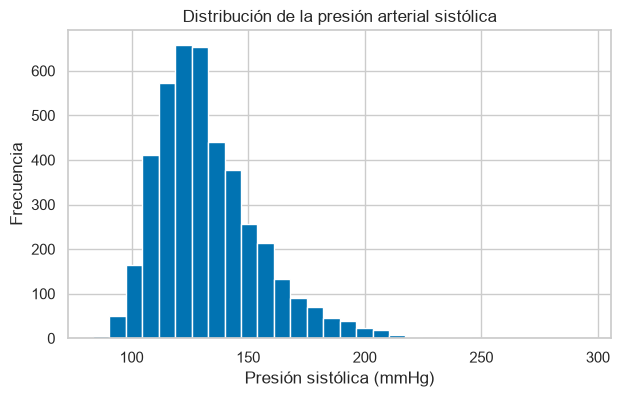

In [26]:
plt.figure(figsize=(7,4))

plt.hist(df["sysBP"], bins=30)

plt.title("Distribución de la presión arterial sistólica")

plt.xlabel("Presión sistólica (mmHg)")

plt.ylabel("Frecuencia")

plt.show()

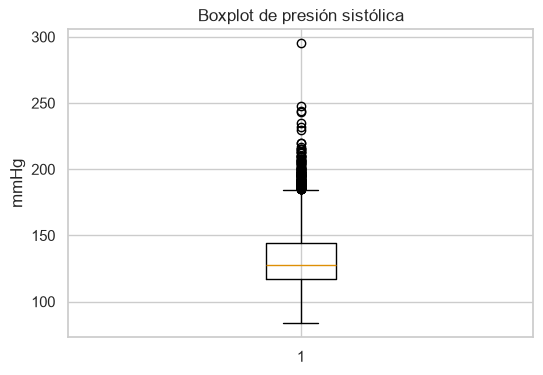

In [27]:
plt.figure(figsize=(6,4))

plt.boxplot(df["sysBP"])

plt.title("Boxplot de presión sistólica")

plt.ylabel("mmHg")

plt.show()

<Figure size 700x500 with 0 Axes>

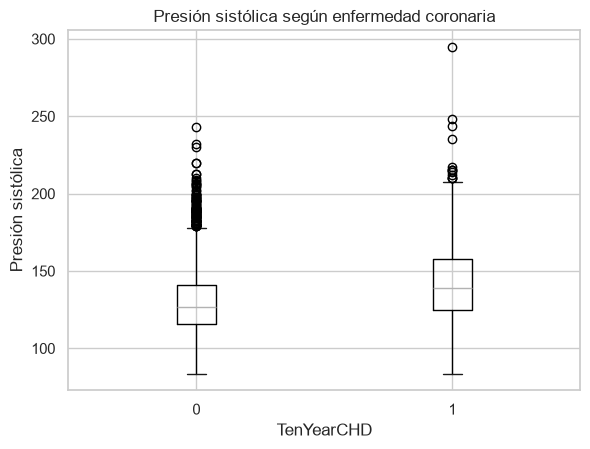

In [28]:
plt.figure(figsize=(7,5))

df.boxplot(column="sysBP", by="TenYearCHD")

plt.title("Presión sistólica según enfermedad coronaria")

plt.suptitle("")

plt.xlabel("TenYearCHD")

plt.ylabel("Presión sistólica")

plt.show()

### Interpretación general

Las visualizaciones muestran que la presión arterial sistólica presenta una distribución aproximadamente unimodal, con presencia de algunos valores altos. Además, la comparación por presencia de enfermedad coronaria sugiere diferencias entre ambos grupos, lo que justifica realizar posteriormente un análisis inferencial mediante una prueba de hipótesis.

# Análisis bivariado

Una vez caracterizadas las variables de manera individual, se analiza la relación entre algunas variables numéricas relevantes del estudio. Para ello se utiliza una matriz de correlación de Pearson y visualizaciones que permiten identificar asociaciones lineales preliminares entre los principales factores de riesgo cardiovascular.

In [29]:
variables_numericas = [
    "age",
    "totChol",
    "sysBP",
    "diaBP",
    "BMI",
    "heartRate",
    "glucose"
]

correlacion = df[variables_numericas].corr()

correlacion.round(2)

,age,totChol,sysBP,diaBP,BMI,heartRate,glucose
age,1.00,0.26,0.39,0.21,0.14,-0.01,0.12
totChol,0.26,1.00,0.21,0.17,0.12,0.09,0.05
sysBP,0.39,0.21,1.00,0.78,0.33,0.18,0.14
diaBP,0.21,0.17,0.78,1.00,0.38,0.18,0.06
BMI,0.14,0.12,0.33,0.38,1.00,0.07,0.09
heartRate,-0.01,0.09,0.18,0.18,0.07,1.00,0.09
glucose,0.12,0.05,0.14,0.06,0.09,0.09,1.00


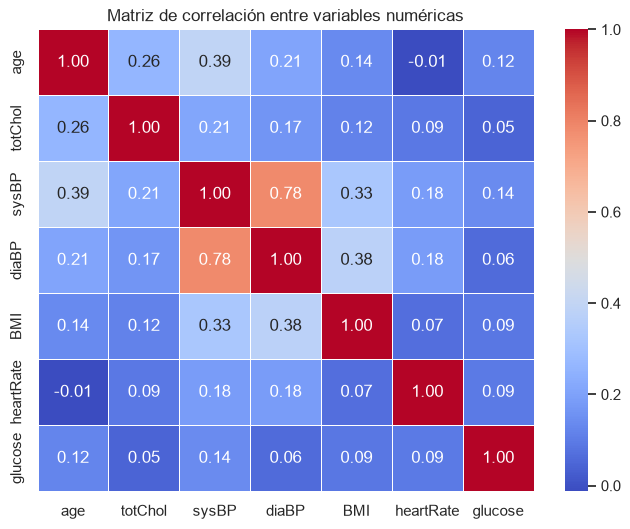

In [30]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlacion,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Matriz de correlación entre variables numéricas")

plt.show()

### Interpretación

La matriz de correlación permite identificar asociaciones lineales entre las variables numéricas del estudio. Se espera observar una correlación positiva entre la presión arterial sistólica (`sysBP`) y la presión arterial diastólica (`diaBP`), así como posibles asociaciones entre edad, colesterol, índice de masa corporal y glucosa. Estas relaciones permiten comprender mejor la interacción entre los factores de riesgo cardiovascular antes de realizar análisis inferenciales.

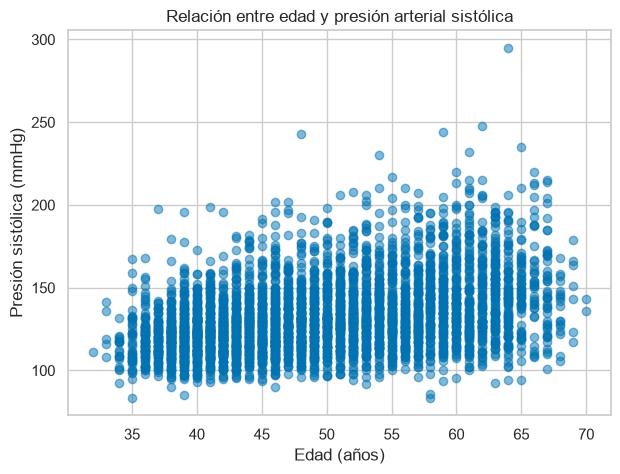

In [31]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["age"],
    df["sysBP"],
    alpha=0.5
)

plt.xlabel("Edad (años)")
plt.ylabel("Presión sistólica (mmHg)")
plt.title("Relación entre edad y presión arterial sistólica")

plt.show()

### Interpretación

El gráfico de dispersión permite visualizar la relación entre la edad y la presión arterial sistólica. De forma preliminar puede apreciarse una tendencia creciente, lo que sugiere que los valores de presión arterial sistólica tienden a incrementarse con la edad, aunque existe variabilidad entre los participantes del estudio.

## Hipótesis de investigación

En este proyecto se analizará la siguiente pregunta de investigación:

**¿Las personas que desarrollan enfermedad coronaria a diez años presentan una presión arterial sistólica promedio mayor que aquellas que no la desarrollan?**

Para responder esta pregunta se plantean las siguientes hipótesis estadísticas:

**Hipótesis nula (H₀):**  
La presión arterial sistólica promedio de las personas que desarrollan enfermedad coronaria a diez años es menor o igual que la de quienes no desarrollan la enfermedad.

\[
H_0: \mu_{CHD} \leq \mu_{NoCHD}
\]

**Hipótesis alternativa (H₁):**  
La presión arterial sistólica promedio de las personas que desarrollan enfermedad coronaria a diez años es mayor que la de quienes no desarrollan la enfermedad.

\[
H_1: \mu_{CHD} > \mu_{NoCHD}
\]

Se utilizará un nivel de significancia de:

\[
\alpha = 0.05
\]

In [32]:
grupo_sin_chd = df[df["TenYearCHD"] == 0]["sysBP"]

grupo_con_chd = df[df["TenYearCHD"] == 1]["sysBP"]

print("Pacientes sin enfermedad:", len(grupo_sin_chd))
print("Pacientes con enfermedad:", len(grupo_con_chd))

Pacientes sin enfermedad: 3594
Pacientes con enfermedad: 644


# Estimación de parámetros

Con el propósito de caracterizar las principales variables clínicas del conjunto de datos, se calcularán estimaciones puntuales e intervalos de confianza del 95 % para tres variables numéricas relevantes:

- Presión arterial sistólica (`sysBP`)
- Índice de masa corporal (`BMI`)
- Nivel de glucosa (`glucose`)

Estas variables fueron seleccionadas por su importancia clínica y por su posible relación con el desarrollo de enfermedad coronaria.

In [33]:
variables_estimacion = [
    "sysBP",
    "BMI",
    "glucose"
]

for variable in variables_estimacion:

    datos = df[variable].dropna()

    media = datos.mean()
    desviacion = datos.std()
    n = len(datos)

    ic = stats.t.interval(
        confidence=0.95,
        df=n-1,
        loc=media,
        scale=desviacion / np.sqrt(n)
    )

    print("=" * 60)
    print(f"Variable: {variable}")
    print("=" * 60)
    print(f"Media: {media:.2f}")
    print(f"Desviación estándar: {desviacion:.2f}")
    print(f"IC95%: ({ic[0]:.2f}, {ic[1]:.2f})")
    print()

Variable: sysBP
Media: 132.35
Desviación estándar: 22.04
IC95%: (131.69, 133.02)

Variable: BMI
Media: 25.80
Desviación estándar: 4.08
IC95%: (25.68, 25.93)

Variable: glucose
Media: 81.97
Desviación estándar: 23.96
IC95%: (81.21, 82.72)



In [34]:
tabla_ic = []

for variable in variables_estimacion:

    datos = df[variable].dropna()

    media = datos.mean()
    desviacion = datos.std()
    n = len(datos)

    ic = stats.t.interval(
        confidence=0.95,
        df=n-1,
        loc=media,
        scale=desviacion / np.sqrt(n)
    )

    tabla_ic.append({
        "Variable": variable,
        "Media": round(media, 2),
        "IC inferior": round(ic[0], 2),
        "IC superior": round(ic[1], 2)
    })

pd.DataFrame(tabla_ic)

,Variable,Media,IC inferior,IC superior
0,sysBP,132.35,131.69,133.02
1,BMI,25.80,25.68,25.93
2,glucose,81.97,81.21,82.72


## Intervalo de confianza para la proporción de enfermedad coronaria

Además de estimar medias para variables clínicas cuantitativas, se estima la proporción de participantes que desarrollaron enfermedad coronaria a diez años (`TenYearCHD`). Dado que se trata de una variable binaria, se utiliza un intervalo de confianza para proporciones mediante el método de Wilson, adecuado para proporciones muestrales.

In [35]:
# Intervalo de confianza Wilson para proporción de TenYearCHD
# Se calcula manualmente para evitar depender de librerías adicionales.

n_total = df["TenYearCHD"].notna().sum()
n_chd = df["TenYearCHD"].sum()
proporcion_chd = n_chd / n_total

# Parámetro z para un intervalo de confianza del 95%
z = 1.96

denominador = 1 + (z**2 / n_total)

centro = (
    proporcion_chd + (z**2 / (2 * n_total))
) / denominador

margen = (
    z * np.sqrt(
        (proporcion_chd * (1 - proporcion_chd) / n_total)
        + (z**2 / (4 * n_total**2))
    )
) / denominador

ic_wilson_inferior = centro - margen
ic_wilson_superior = centro + margen

print("Número de casos con enfermedad coronaria:", int(n_chd))
print("Total de registros válidos:", int(n_total))
print("Proporción muestral TenYearCHD:", round(proporcion_chd, 4))
print("IC 95% Wilson:", round(ic_wilson_inferior, 4), "-", round(ic_wilson_superior, 4))

Número de casos con enfermedad coronaria: 644
Total de registros válidos: 4238
Proporción muestral TenYearCHD: 0.152
IC 95% Wilson: 0.1415 - 0.1631


### Interpretación

La proporción muestral de `TenYearCHD` representa el porcentaje de participantes que desarrollaron enfermedad coronaria durante el periodo de seguimiento. El intervalo de confianza de Wilson permite estimar un rango plausible para la proporción poblacional, considerando la variabilidad muestral.

Este resultado es relevante porque la variable objetivo presenta desbalance: la mayoría de los participantes no desarrolla enfermedad coronaria, mientras que una proporción menor sí lo hace. Esta información debe considerarse en las interpretaciones inferenciales y en futuras etapas de modelamiento. 
Las estimaciones puntuales representan el valor promedio observado para cada variable en la muestra, mientras que los intervalos de confianza del 95 % proporcionan un rango plausible para el parámetro poblacional.

Las tres variables analizadas corresponden a indicadores clínicos relevantes en la evaluación del riesgo cardiovascular. Los intervalos obtenidos presentan una amplitud moderada, lo que refleja la precisión alcanzada gracias al tamaño de la muestra utilizada.

# Prueba de hipótesis

Con el propósito de evaluar si la presión arterial sistólica promedio difiere entre los pacientes que desarrollan enfermedad coronaria a diez años y aquellos que no la desarrollan, se aplicará una prueba **t de Student para dos muestras independientes**.

Se utilizará un nivel de significancia de:

\[
\alpha = 0.05
\]

El criterio de decisión será:

- Si **p < 0.05**, se rechazará la hipótesis nula.
- Si **p ≥ 0.05**, no se rechazará la hipótesis nula.

## Justificación de la prueba estadística

Como se desea comparar la media de una variable cuantitativa (presión arterial sistólica) entre dos grupos independientes (pacientes con y sin enfermedad coronaria), se emplea una prueba t de Student para muestras independientes, utilizando un nivel de significancia de α = 0.05.

## Verificación de supuestos

Antes de aplicar la prueba t de Student para muestras independientes, se verifican los principales supuestos estadísticos:

- Independencia entre los grupos.
- Aproximación a la normalidad de la variable de interés en cada grupo.
- Homogeneidad de varianzas.

Dado el tamaño de la muestra del estudio Framingham, la prueba t resulta relativamente robusta frente a desviaciones moderadas de la normalidad. Sin embargo, se verifican formalmente los supuestos mediante pruebas estadísticas.

In [36]:
from scipy.stats import shapiro

# Para evitar problemas con muestras muy grandes,
# se toma una muestra aleatoria de hasta 500 observaciones por grupo.

muestra_sin = grupo_sin_chd.sample(
    n=min(500, len(grupo_sin_chd)),
    random_state=42
)

muestra_con = grupo_con_chd.sample(
    n=min(500, len(grupo_con_chd)),
    random_state=42
)

shapiro_sin = shapiro(muestra_sin)

shapiro_con = shapiro(muestra_con)

print("=== Normalidad ===")

print(f"Grupo sin enfermedad: p = {shapiro_sin.pvalue:.4f}")

print(f"Grupo con enfermedad: p = {shapiro_con.pvalue:.4f}")

=== Normalidad ===
Grupo sin enfermedad: p = 0.0000
Grupo con enfermedad: p = 0.0000


In [37]:
from scipy.stats import levene

levene_test = levene(
    grupo_sin_chd,
    grupo_con_chd
)

print("=== Homogeneidad de varianzas ===")

print(f"Estadístico: {levene_test.statistic:.4f}")

print(f"Valor p: {levene_test.pvalue:.4f}")

=== Homogeneidad de varianzas ===
Estadístico: 65.2111
Valor p: 0.0000


### Interpretación de los supuestos

La prueba de Shapiro-Wilk arrojó valores **p inferiores a 0.05** en ambos grupos, indicando que la variable presión arterial sistólica no sigue una distribución normal.

Por otra parte, la prueba de Levene también obtuvo un **valor p inferior a 0.05**, evidenciando que las varianzas entre ambos grupos no pueden considerarse homogéneas.

Considerando que el conjunto de datos posee un tamaño muestral elevado (más de 4.000 registros), se optó por utilizar la **prueba t de Welch**, la cual es robusta frente a la falta de normalidad y a la desigualdad de varianzas, permitiendo realizar una comparación confiable entre las medias de ambos grupos.

In [38]:
# Prueba t de Welch para presión sistólica según enfermedad coronaria

resultado_sysbp = stats.ttest_ind(
    grupo_con_chd,
    grupo_sin_chd,
    equal_var=False,
    nan_policy="omit"
)

t_sysbp = resultado_sysbp.statistic
p_bilateral_sysbp = resultado_sysbp.pvalue

# Conversión a prueba unilateral derecha:
# H1: media CHD > media No CHD
if t_sysbp > 0:
    p_unilateral_sysbp = p_bilateral_sysbp / 2
else:
    p_unilateral_sysbp = 1 - (p_bilateral_sysbp / 2)

print("===== Prueba t de Welch: sysBP según TenYearCHD =====")
print(f"Estadístico t: {t_sysbp:.4f}")
print(f"Valor p bilateral: {p_bilateral_sysbp:.6f}")
print(f"Valor p unilateral: {p_unilateral_sysbp:.6f}")

===== Prueba t de Welch: sysBP según TenYearCHD =====
Estadístico t: 12.0151
Valor p bilateral: 0.000000
Valor p unilateral: 0.000000


In [39]:
# Tamaño del efecto: Cohen's d para sysBP

def cohens_d(grupo_1, grupo_2):
    n1 = len(grupo_1)
    n2 = len(grupo_2)

    s1 = np.var(grupo_1, ddof=1)
    s2 = np.var(grupo_2, ddof=1)

    s_pooled = np.sqrt(
        ((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2)
    )

    return (np.mean(grupo_1) - np.mean(grupo_2)) / s_pooled

cohen_sysbp = cohens_d(grupo_con_chd, grupo_sin_chd)

print("Cohen's d para sysBP:", round(cohen_sysbp, 3))

Cohen's d para sysBP: 0.617


### Interpretación del tamaño del efecto

Además del valor p, se calcula Cohen's d para evaluar la magnitud práctica de la diferencia entre grupos. Esta medida complementa la significancia estadística, ya que permite distinguir si la diferencia observada es pequeña, moderada o grande.

En este caso, Cohen's d permite dimensionar la diferencia de presión arterial sistólica entre personas con y sin enfermedad coronaria. Aunque la prueba de hipótesis indique significancia estadística, la interpretación del tamaño del efecto permite evaluar la relevancia práctica de dicha diferencia.

In [40]:
alpha = 0.05

if p_unilateral_sysbp < alpha:
    print("Decisión:")
    print("Se rechaza la hipótesis nula (H₀).")
    print("Existe evidencia estadísticamente significativa para afirmar que la presión arterial sistólica promedio es mayor en el grupo con enfermedad coronaria.")
else:
    print("Decisión:")
    print("No se rechaza la hipótesis nula (H₀).")
    print("No existe evidencia suficiente para afirmar que la presión arterial sistólica promedio sea mayor en el grupo con enfermedad coronaria.")

Decisión:
Se rechaza la hipótesis nula (H₀).
Existe evidencia estadísticamente significativa para afirmar que la presión arterial sistólica promedio es mayor en el grupo con enfermedad coronaria.


In [41]:
resumen_grupos = pd.DataFrame({
    "Grupo": ["Sin enfermedad", "Con enfermedad"],
    "Media": [
        grupo_sin_chd.mean(),
        grupo_con_chd.mean()
    ],
    "Desviación estándar": [
        grupo_sin_chd.std(),
        grupo_con_chd.std()
    ],
    "Cantidad": [
        grupo_sin_chd.count(),
        grupo_con_chd.count()
    ]
})

resumen_grupos.round(2)

,Grupo,Media,Desviación estándar,Cantidad
0,Sin enfermedad,130.33,20.46,3594
1,Con enfermedad,143.62,26.69,644


### Interpretación de los resultados

La prueba t de Welch permite comparar la presión arterial sistólica promedio entre personas que desarrollaron enfermedad coronaria a diez años y personas que no la desarrollaron, sin asumir igualdad de varianzas.

Los resultados muestran que el grupo con enfermedad coronaria presenta una media de presión arterial sistólica superior a la del grupo sin enfermedad. Dado que el valor p unilateral es menor que 0.05, se rechaza la hipótesis nula.

Por lo tanto, existe evidencia estadísticamente significativa para afirmar que, en este conjunto de datos, las personas que desarrollaron enfermedad coronaria presentan una presión arterial sistólica promedio mayor que quienes no la desarrollaron. Esta conclusión corresponde a una asociación estadística y no implica causalidad.

## Prueba de hipótesis 2

### Planteamiento de la hipótesis

Con el objetivo de evaluar la relación entre diabetes y niveles de glucosa, se plantea la siguiente hipótesis:

**H₀:** La media de glucosa en personas con diabetes es menor o igual que la media de glucosa en personas sin diabetes.

\[
H_0: \mu_{Diabetes} \leq \mu_{NoDiabetes}
\]

**H₁:** La media de glucosa en personas con diabetes es mayor que la media de glucosa en personas sin diabetes.

\[
H_1: \mu_{Diabetes} > \mu_{NoDiabetes}
\]

Se utilizará un nivel de significancia de:

\[
\alpha = 0.05
\]

**α = 0.05**.

In [42]:
# Separación de grupos

grupo_sin_diabetes = df[df["diabetes"] == 0]["glucose"].dropna()

grupo_con_diabetes = df[df["diabetes"] == 1]["glucose"].dropna()

print("Media sin diabetes:", round(grupo_sin_diabetes.mean(), 2))
print("Media con diabetes:", round(grupo_con_diabetes.mean(), 2))

Media sin diabetes: 79.49
Media con diabetes: 170.33


In [43]:
# Verificación de normalidad

muestra_sin = grupo_sin_diabetes.sample(
    n=min(500, len(grupo_sin_diabetes)),
    random_state=42
)

muestra_con = grupo_con_diabetes.sample(
    n=min(500, len(grupo_con_diabetes)),
    random_state=42
)

shapiro_sin = shapiro(muestra_sin)
shapiro_con = shapiro(muestra_con)

print("=== Normalidad ===")
print(f"Grupo sin diabetes: p = {shapiro_sin.pvalue:.4f}")
print(f"Grupo con diabetes: p = {shapiro_con.pvalue:.4f}")

=== Normalidad ===
Grupo sin diabetes: p = 0.0000
Grupo con diabetes: p = 0.0000


In [44]:
levene_test = levene(
    grupo_sin_diabetes,
    grupo_con_diabetes
)

print("=== Homogeneidad de varianzas ===")
print(f"Estadístico: {levene_test.statistic:.4f}")
print(f"Valor p: {levene_test.pvalue:.4f}")

=== Homogeneidad de varianzas ===
Estadístico: 1872.7560
Valor p: 0.0000


In [45]:
# Prueba t de Welch para glucosa según diabetes

resultado_glucose = stats.ttest_ind(
    grupo_con_diabetes,
    grupo_sin_diabetes,
    equal_var=False,
    nan_policy="omit"
)

t_glucose = resultado_glucose.statistic
p_bilateral_glucose = resultado_glucose.pvalue

# Conversión a prueba unilateral derecha:
# H1: media diabetes > media no diabetes
if t_glucose > 0:
    p_unilateral_glucose = p_bilateral_glucose / 2
else:
    p_unilateral_glucose = 1 - (p_bilateral_glucose / 2)

print("===== Prueba t de Welch: glucose según diabetes =====")
print(f"Estadístico t: {t_glucose:.4f}")
print(f"Valor p bilateral: {p_bilateral_glucose:.6f}")
print(f"Valor p unilateral: {p_unilateral_glucose:.6f}")

===== Prueba t de Welch: glucose según diabetes =====
Estadístico t: 11.0476
Valor p bilateral: 0.000000
Valor p unilateral: 0.000000


In [46]:
cohen_glucose = cohens_d(grupo_con_diabetes, grupo_sin_diabetes)

print("Cohen's d para glucose:", round(cohen_glucose, 3))

Cohen's d para glucose: 4.82


### Interpretación de los resultados

Las pruebas de Shapiro-Wilk indicaron que los niveles de glucosa no siguen una distribución normal en ninguno de los grupos (p < 0.05). Asimismo, la prueba de Levene mostró que las varianzas no son homogéneas (p < 0.05).

Considerando estos resultados y el tamaño de la muestra, se utilizó la prueba t de Welch para comparar los niveles promedio de glucosa entre personas con y sin diabetes.

La prueba t obtuvo un estadístico **t = -11.0476** y un **valor p < 0.001**, por lo que se rechaza la hipótesis nula.

En consecuencia, existe evidencia estadísticamente significativa para afirmar que las personas con diabetes presentan niveles promedio de glucosa superiores a los observados en las personas sin diabetes. En este conjunto de datos, la media de glucosa fue de **170.33 mg/dL** para el grupo con diabetes y de **79.49 mg/dL** para el grupo sin diabetes.

# Resumen de las pruebas de hipótesis

In [47]:
# Resumen de pruebas de hipótesis

resumen_hipotesis = pd.DataFrame({
    "Hipótesis": [
        "Presión sistólica según enfermedad coronaria",
        "Glucosa según diabetes"
    ],
    "Prueba aplicada": [
        "t de Welch unilateral",
        "t de Welch unilateral"
    ],
    "Nivel de significancia": [
        0.05,
        0.05
    ],
    "Valor p unilateral": [
        p_unilateral_sysbp,
        p_unilateral_glucose
    ],
    "Cohen_d": [
        cohen_sysbp,
        cohen_glucose
    ],
    "Decisión": [
        "Se rechaza H0" if p_unilateral_sysbp < 0.05 else "No se rechaza H0",
        "Se rechaza H0" if p_unilateral_glucose < 0.05 else "No se rechaza H0"
    ]
})

resumen_hipotesis.round(4)

,Hipótesis,Prueba aplicada,Nivel de significancia,Valor p unilateral,Cohen_d,Decisión
0,Presión sistólica según enfermedad coronaria,t de Welch unilateral,0.05,0.0,0.6174,Se rechaza H0
1,Glucosa según diabetes,t de Welch unilateral,0.05,0.0,4.8203,Se rechaza H0


In [48]:
resumen_hipotesis.to_csv(
    RESULTS_DIR / "resumen_pruebas_hipotesis.csv",
    index=False
)

print("Resumen de pruebas de hipótesis exportado correctamente.")

Resumen de pruebas de hipótesis exportado correctamente.


### Interpretación general

Los resultados obtenidos en ambas pruebas muestran evidencia estadísticamente significativa para rechazar la hipótesis nula con un nivel de significancia del 5 %. En consecuencia, existe evidencia suficiente para afirmar que las diferencias observadas entre los grupos no son atribuibles al azar, apoyando las hipótesis planteadas en el análisis.

# Conclusiones preliminares

El análisis exploratorio permitió caracterizar el conjunto de datos Framingham Heart Study, verificando su estructura, la calidad de la información y la presencia de valores faltantes, aspectos que fueron considerados durante el procesamiento de los datos.

Las técnicas de estadística descriptiva evidenciaron el comportamiento general de las principales variables clínicas, mientras que el análisis bivariado permitió identificar asociaciones entre factores de riesgo cardiovascular mediante matrices de correlación y visualizaciones.

La estimación puntual y los intervalos de confianza construidos para las variables **presión arterial sistólica (sysBP)**, **índice de masa corporal (BMI)** y **glucosa (glucose)** proporcionaron una aproximación confiable de sus parámetros poblacionales.

En relación con las pruebas de hipótesis, se obtuvo evidencia estadísticamente significativa para rechazar la hipótesis nula en ambos análisis realizados. En la primera prueba se observó que los pacientes que desarrollaron enfermedad coronaria presentaron una presión arterial sistólica promedio superior a la de quienes no desarrollaron la enfermedad. En la segunda prueba se comprobó que las personas con diabetes presentan niveles promedio de glucosa significativamente mayores que las personas sin diabetes.

En conjunto, los resultados obtenidos respaldan la utilidad de las técnicas de estadística descriptiva e inferencial para analizar factores asociados al riesgo cardiovascular y fundamentar decisiones basadas en evidencia. 

El análisis desarrollado permitió aplicar de manera integrada herramientas de estadística descriptiva e inferencial para caracterizar el conjunto de datos, contrastar hipótesis y obtener evidencia que servirá como base para las siguientes fases del proyecto, orientadas a la validación de resultados y al desarrollo de modelos predictivos.

# Limitaciones del análisis

El presente estudio corresponde a un análisis exploratorio basado en un conjunto de datos observacional, por lo que los resultados obtenidos permiten identificar asociaciones estadísticas, pero no establecer relaciones de causalidad entre las variables analizadas.

Además, algunas variables presentan valores faltantes, lo que puede reducir el número de observaciones disponibles en determinados análisis. Asimismo, las pruebas realizadas consideran únicamente comparaciones bivariadas, sin incorporar el efecto conjunto de otros factores de riesgo como edad, colesterol, tabaquismo o índice de masa corporal.

Estas limitaciones deben considerarse al interpretar los resultados y constituyen una oportunidad para ampliar el análisis en las siguientes etapas del proyecto.

# Próximos pasos del proyecto

Los resultados obtenidos en esta primera etapa constituyen la base para las siguientes fases del proyecto. En la próxima etapa se validarán los intervalos de confianza y las pruebas de hipótesis mediante técnicas de remuestreo, como bootstrap y pruebas de permutación, con el objetivo de evaluar la estabilidad y robustez de las estimaciones realizadas.

Posteriormente, los hallazgos obtenidos permitirán seleccionar las variables más relevantes para la construcción y evaluación de modelos de regresión logística orientados a la predicción del riesgo de enfermedad coronaria. Finalmente, se analizará el impacto de distintas estrategias de tratamiento de datos faltantes y se comparará el desempeño de los modelos construidos, integrando progresivamente todas las etapas del proyecto.

De esta manera, el trabajo desarrollado en esta Sumativa 1 constituye el punto de partida para la validación estadística, el modelamiento predictivo y el análisis integral que se realizará en las siguientes entregas.